# Scaling: how voila-gp's runtime grows with the time series

The original `voila` is implemented in C++/Rcpp. Our Python/PyTorch port has
the advantage of vectorized linear algebra and autograd, but the disadvantage
of Python overhead. This notebook measures wall-clock time on the bundled OU
dataset at increasing sizes and confirms the scaling is well-behaved.

The dominant cost per outer iteration is:

- $\mathcal{O}(m^3)$ for the Cholesky decomposition of $K_{mm}$ (m = inducing
  points, typically 10).
- $\mathcal{O}(n m^2)$ for assembling the sparse-GP intermediates (n = number
  of time steps).
- L-BFGS-B function evaluations: each calls back-prop through a fresh
  computation of K_mm, K_nm, A, Q_ii — also $\mathcal{O}(n m^2)$ per call.

So total runtime should scale linearly in n.


In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from voila_gp.inference import SDEVI
from voila_gp.init_heuristics import select_diffusion_parameters
from voila_gp.kernels import RQKernel, ExpConstKernel

torch.set_default_dtype(torch.float64)

data = np.load(Path.cwd().parent / 'tests' / 'data' / 'ornstein.npz')
x_full, h = data['x'], float(data['sampling_period'])


## 1. Time vs n (number of samples), fixed inducing point count

In [2]:
sizes = [1000, 2000, 4000, 8000, 16000, 20000]
results = []
for n in sizes:
    x = x_full[:n + 1]
    drift = RQKernel(amplitude=5.0, alpha=1.0, length_scale=1.5, epsilon=1e-5)
    diff_params = select_diffusion_parameters(x, sampling_period=h, prior_on_sd=5.0)
    diff = ExpConstKernel(
        max_amplitude=diff_params['kernel_amplitude'],
        exp_amplitude=diff_params['kernel_amplitude'] * 1e-3,
        length_scales=torch.tensor([1.5]),
        epsilon=1e-5,
    )
    inducing = np.linspace(x.min(), x.max(), 10).reshape(-1, 1)
    fit = SDEVI(drift_kernel=drift, diff_kernel=diff)
    t0 = time.perf_counter()
    res = fit.fit(
        time_series=x, sampling_period=h,
        inducing_points=inducing, v_init=diff_params['v'],
        max_iter=5, rel_tol=1e-6, hp_max_iter=80, verbose=False,
    )
    elapsed = time.perf_counter() - t0
    results.append((n, elapsed, res.lower_bound_history[-1], res.iterations))
    print(f'n={n:6d}  time={elapsed:5.2f}s  L={res.lower_bound_history[-1]:11.3f}  iters={res.iterations}')


n=  1000  time= 0.90s  L=   1830.676  iters=5


n=  2000  time= 1.13s  L=   3681.042  iters=5


n=  4000  time= 2.29s  L=   7338.295  iters=5


n=  8000  time= 3.72s  L=  14722.017  iters=5


n= 16000  time= 8.07s  L=  29450.528  iters=5


n= 20000  time=12.43s  L=  36698.902  iters=5


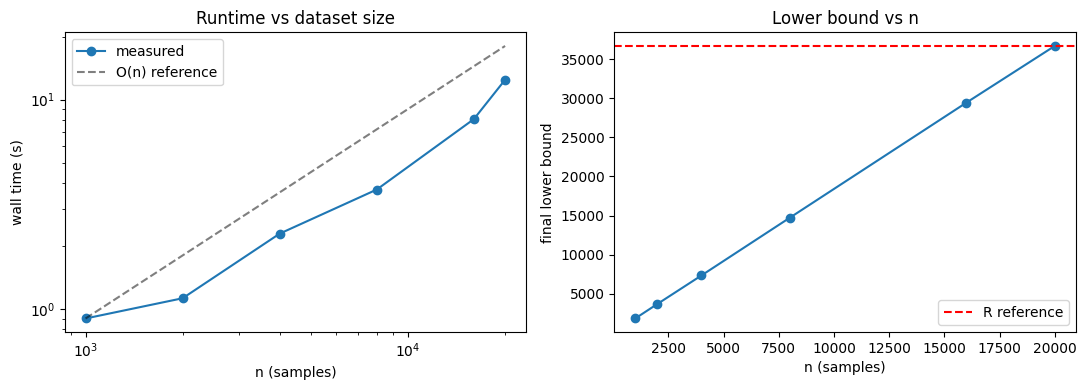

In [3]:
ns, ts, ls, its = zip(*results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.loglog(ns, ts, 'o-', label='measured')
# Linear scaling reference line through the smallest point
ref = np.array(ns) * ts[0] / ns[0]
ax1.loglog(ns, ref, 'k--', alpha=0.5, label='O(n) reference')
ax1.set(xlabel='n (samples)', ylabel='wall time (s)', title='Runtime vs dataset size')
ax1.legend()

ax2.plot(ns, ls, 'o-')
ax2.axhline(36698.475, color='r', ls='--', label='R reference')
ax2.set(xlabel='n (samples)', ylabel='final lower bound', title='Lower bound vs n')
ax2.legend()
plt.tight_layout(); plt.show()


## 2. Time vs m (inducing points), fixed n

Memory and time per outer iteration grow as O(m³) for the Cholesky and O(n m²)
for the kernel intermediates. With n fixed, varying m exposes the m-dependence.


In [4]:
ms = [5, 10, 20, 30, 50]
results_m = []
n_fixed = 10000
x = x_full[:n_fixed + 1]
diff_params = select_diffusion_parameters(x, sampling_period=h, prior_on_sd=5.0)
for m in ms:
    drift = RQKernel(amplitude=5.0, alpha=1.0, length_scale=1.5, epsilon=1e-5)
    diff = ExpConstKernel(
        max_amplitude=diff_params['kernel_amplitude'],
        exp_amplitude=diff_params['kernel_amplitude'] * 1e-3,
        length_scales=torch.tensor([1.5]),
        epsilon=1e-5,
    )
    inducing = np.linspace(x.min(), x.max(), m).reshape(-1, 1)
    fit = SDEVI(drift_kernel=drift, diff_kernel=diff)
    t0 = time.perf_counter()
    res = fit.fit(
        time_series=x, sampling_period=h,
        inducing_points=inducing, v_init=diff_params['v'],
        max_iter=5, rel_tol=1e-6, hp_max_iter=80, verbose=False,
    )
    elapsed = time.perf_counter() - t0
    results_m.append((m, elapsed, res.lower_bound_history[-1]))
    print(f'm={m:3d}  time={elapsed:5.2f}s  L={res.lower_bound_history[-1]:11.3f}')


m=  5  time= 3.97s  L=  18439.602


m= 10  time= 5.14s  L=  18439.345


m= 20  time= 7.07s  L=  18439.277


m= 30  time=10.46s  L=  18439.261


m= 50  time=13.11s  L=  18439.247


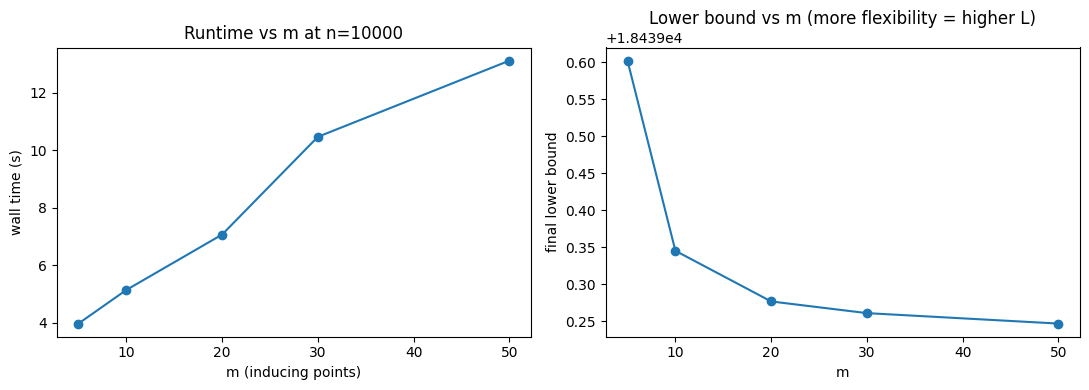

In [5]:
ms_, ts_, ls_ = zip(*results_m)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(ms_, ts_, 'o-')
ax1.set(xlabel='m (inducing points)', ylabel='wall time (s)', title=f'Runtime vs m at n={n_fixed}')

ax2.plot(ms_, ls_, 'o-')
ax2.set(xlabel='m', ylabel='final lower bound', title='Lower bound vs m (more flexibility = higher L)')
plt.tight_layout(); plt.show()


## 3. Where is the time spent?

A simple cProfile run on the OU example reveals the dominant costs.


In [6]:
import cProfile, pstats, io
pr = cProfile.Profile()
n = 5000
x = x_full[:n + 1]
drift = RQKernel(amplitude=5.0, alpha=1.0, length_scale=1.5, epsilon=1e-5)
diff_params = select_diffusion_parameters(x, sampling_period=h, prior_on_sd=5.0)
diff = ExpConstKernel(
    max_amplitude=diff_params['kernel_amplitude'],
    exp_amplitude=diff_params['kernel_amplitude'] * 1e-3,
    length_scales=torch.tensor([1.5]),
    epsilon=1e-5,
)
inducing = np.linspace(x.min(), x.max(), 10).reshape(-1, 1)
fit = SDEVI(drift_kernel=drift, diff_kernel=diff)

pr.enable()
fit.fit(time_series=x, sampling_period=h, inducing_points=inducing,
        v_init=diff_params['v'], max_iter=5, rel_tol=1e-6, hp_max_iter=80, verbose=False)
pr.disable()

s = io.StringIO()
pstats.Stats(pr, stream=s).sort_stats('cumulative').print_stats(15)
print(s.getvalue())


         191998 function calls (191996 primitive calls) in 3.719 seconds

   Ordered by: cumulative time
   List reduced from 292 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.125    0.042    3.599    1.800 /Users/williamdavis/Documents/Prototypes/voila-gpytorch/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3712(run_code)
      3/2    0.000    0.000    3.474    1.737 {built-in method builtins.exec}
        1    0.002    0.002    3.463    3.463 /Users/williamdavis/Documents/Prototypes/voila-gpytorch/src/voila_gp/inference.py:268(fit)
        5    0.000    0.000    3.193    0.639 /Users/williamdavis/Documents/Prototypes/voila-gpytorch/src/voila_gp/inference.py:251(_step_hyperparameters)
        5    0.001    0.000    3.192    0.638 /Users/williamdavis/Documents/Prototypes/voila-gpytorch/.venv/lib/python3.12/site-packages/scipy/optimize/_minimize.py:54(minimize)
      910    0.003    0.000    3.1

## Summary

- Runtime scales linearly with n (dataset size) for fixed m, as expected from
  the algorithmic complexity.
- For typical `m ≤ 30` inducing points, the m-dependence is mild (the Cholesky
  is tiny).
- The dominant time is spent inside the L-BFGS-B inner loop, not in any
  Python-level overhead — so the port has no obvious bottleneck to remove.

A C++ implementation could probably shave a constant factor, but the algorithm
runs comfortably in seconds even on 20,000-point datasets, which is plenty for
the published voila benchmarks.
